# Extended Analysis Results

Inspection notebook for the extended-analysis pipeline output.
Read top-to-bottom; no interactivity. All plots are reproducible matplotlib cells.

**Single-run data** (`ext_*.csv`) = `final_lr010_seed0` only.  
**Cross-seed / per-LR data** = `study_trajectories.csv`, `study_milestones.csv`, `study_timing_tests.csv` (15 runs).

In [1]:
# ── configuration ────────────────────────────────────────────────────────────
LOCK_K = 52   # edit as needed

import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from IPython.display import display, Image

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 9})

ROOT = os.path.join(os.path.dirname(os.getcwd()), 'thesis') if 'notebooks' in os.getcwd() else os.getcwd()
AGG  = os.path.join(ROOT, 'thesis_results', '_aggregate')
FIGS = os.path.join(ROOT, 'thesis_results', '_figs')
EXT  = os.path.join(ROOT, 'thesis_results', 'ext_sample')

# ── loaders ──────────────────────────────────────────────────────────────────
def load(path):
    if not os.path.exists(path):
        print(f'[SKIP] not found: {path}')
        return None
    return pd.read_csv(path)

def show(df, n=6, decimals=4):
    if df is None:
        return
    display(df.head(n).round(decimals))

def show_png(name):
    p = os.path.join(FIGS, name)
    if os.path.exists(p):
        display(Image(p, width=800))
    else:
        print(f'[SKIP] PNG not found: {p}')

print('ROOT:', ROOT)
print('LOCK_K:', LOCK_K)

ROOT: C:\Users\gabri\thesis\thesis
LOCK_K: 52


---
## Chapter 0 — Data Overview

File listing and schema dump for every CSV. No plotting here.

In [2]:
# ── glob each folder ─────────────────────────────────────────────────────────
for folder, label in [(AGG, '_aggregate'), (FIGS, '_figs'), (EXT, 'ext_sample')]:
    files = sorted(glob.glob(os.path.join(folder, '*')))
    print(f'\n{label}/')
    for f in files:
        print(' ', os.path.basename(f))


_aggregate/

_figs/

ext_sample/


In [3]:
# ── schema dump ──────────────────────────────────────────────────────────────
csv_files = {
    'study_trajectories':  os.path.join(AGG, 'study_trajectories.csv'),
    'study_milestones':    os.path.join(AGG, 'study_milestones.csv'),
    'study_timing_tests':  os.path.join(AGG, 'study_timing_tests.csv'),
    'ext_similarity':      os.path.join(EXT, 'ext_similarity.csv'),
    'ext_subspace':        os.path.join(EXT, 'ext_subspace.csv'),
    'ext_rank_accuracy':   os.path.join(EXT, 'ext_rank_accuracy.csv'),
    'ext_fisher':          os.path.join(EXT, 'ext_fisher.csv'),
    'ext_probe_functional':os.path.join(EXT, 'ext_probe_functional.csv'),
}

dfs = {}
for name, path in csv_files.items():
    df = load(path)
    dfs[name] = df
    if df is not None:
        print(f'\n=== {name} ===' )
        print(f'  shape : {df.shape}')
        print(f'  cols  : {df.columns.tolist()}')
        display(df.head(3).round(4))

[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\_aggregate\study_trajectories.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\_aggregate\study_milestones.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\_aggregate\study_timing_tests.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\ext_sample\ext_similarity.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\ext_sample\ext_subspace.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\ext_sample\ext_rank_accuracy.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\ext_sample\ext_fisher.csv
[SKIP] not found: C:\Users\gabri\thesis\thesis\thesis_results\ext_sample\ext_probe_functional.csv


In [4]:
# ── detect key ranges ────────────────────────────────────────────────────────
if dfs.get('ext_subspace') is not None:
    sub = dfs['ext_subspace']
    K_VALUES  = sorted(sub.k.unique())
    EPOCHS_EXT = sorted(sub.epoch.unique())
    print('Available k values :', K_VALUES)
    print('Available epochs (ext_subspace):', EPOCHS_EXT)

if dfs.get('study_trajectories') is not None:
    traj = dfs['study_trajectories']
    LR_VALUES = sorted(traj.lr.unique())
    print('LR values (study)   :', LR_VALUES)

print()
print('Locally available   : study_trajectories, study_milestones, study_timing_tests, ext_sample/*.csv, _figs/*.png')
print('Cluster-only        : remaining 14 per-run ext_*.csv files, threshold sweep raw data')


Locally available   : study_trajectories, study_milestones, study_timing_tests, ext_sample/*.csv, _figs/*.png
Cluster-only        : remaining 14 per-run ext_*.csv files, threshold sweep raw data


---
## Chapter 1 — Headline Timing Result

**Core claim:** sufficiency is reached before (or at the same epoch as) subspace lock,
which in turn precedes CKA stabilization, which precedes SVCCA stabilization.
Ordering `suff < lock < CKA < SVCCA` is the robust claim; absolute gaps are threshold-dependent
(see Chapter 6).

In [5]:
# ── study_timing_tests table ─────────────────────────────────────────────────
timing = dfs['study_timing_tests']
if timing is not None:
    display(timing.round(4))

In [6]:
# ── forest / bar plot of pooled mean_gap with CI ─────────────────────────────
timing = dfs['study_timing_tests']
if timing is not None:
    pooled = timing[timing.group == 'pooled'].copy()
    if pooled.empty:
        print('[SKIP] no pooled rows in study_timing_tests')
    else:
        gap_labels = {'gap_cka': 'CKA stab − suff', 'gap_svcca': 'SVCCA stab − suff',
                      'gap_lock_vs_cka': 'Subspace lock − CKA stab'}
        gaps = ['gap_cka', 'gap_svcca', 'gap_lock_vs_cka']
        rows = pooled[pooled.gap.isin(gaps)].set_index('gap')

        fig, ax = plt.subplots(figsize=(6, 3))
        colors = ['#4878CF', '#6ACC65', '#D65F5F']
        y_pos  = range(len(gaps))
        for i, g in enumerate(gaps):
            if g not in rows.index:
                continue
            r = rows.loc[g]
            ax.barh(i, r.mean_gap, xerr=[[r.mean_gap - r.ci_lo], [r.ci_hi - r.mean_gap]],
                    color=colors[i], capsize=4, alpha=0.85, height=0.5)
        ax.axvline(0, color='k', lw=0.8, ls='--')
        ax.set_yticks(list(y_pos))
        ax.set_yticklabels([gap_labels.get(g, g) for g in gaps])
        ax.set_xlabel('Epoch gap (pooled, 15 runs)')
        ax.set_title('Timing gaps: stabilization vs sufficiency (pooled 95 % CI)')
        plt.tight_layout()
        plt.show()

        # per-LR breakdown
        per_lr = timing[timing.group != 'pooled'].copy()
        fig2, axes = plt.subplots(1, len(per_lr.group.unique()), figsize=(10, 3), sharey=True)
        for ax2, (grp, gdf) in zip(axes, per_lr.groupby('group')):
            gdf = gdf.set_index('gap')
            for i, g in enumerate(gaps):
                if g not in gdf.index:
                    continue
                r = gdf.loc[g]
                ax2.barh(i, r.mean_gap, xerr=[[r.mean_gap - r.ci_lo], [r.ci_hi - r.mean_gap]],
                         color=colors[i], capsize=4, alpha=0.80, height=0.5)
            ax2.axvline(0, color='k', lw=0.8, ls='--')
            ax2.set_title(grp)
            ax2.set_yticks(list(range(len(gaps))))
            ax2.set_yticklabels([gap_labels.get(g, g) for g in gaps])
        fig2.suptitle('Timing gaps per LR')
        plt.tight_layout()
        plt.show()

In [7]:
# ── study_milestones table ────────────────────────────────────────────────────
ms = dfs['study_milestones']
if ms is not None:
    display(ms.round(2))

---
## Chapter 2 — Similarity Trajectories

Pregenerated figure followed by a from-scratch per-LR rebuild from `study_trajectories.csv`.

In [8]:
# ── pregenerated PNG ─────────────────────────────────────────────────────────
show_png('fig_timing.png')

[SKIP] PNG not found: C:\Users\gabri\thesis\thesis\thesis_results\_figs\fig_timing.png


In [9]:
# ── from-scratch: per-LR trajectories ────────────────────────────────────────
traj = dfs['study_trajectories']
if traj is not None:
    lrs = sorted(traj.lr.unique())
    metrics = [
        ('test_acc',            'Probe test acc'),
        ('cka_debiased_tofinal','CKA (debiased) to final'),
        ('svcca_tofinal',       'SVCCA to final'),
    ]
    fig, axes = plt.subplots(len(metrics), len(lrs),
                             figsize=(4 * len(lrs), 3 * len(metrics)),
                             sharex=True)
    if len(lrs) == 1:
        axes = axes.reshape(-1, 1)
    if len(metrics) == 1:
        axes = axes.reshape(1, -1)

    for col, lr in enumerate(lrs):
        sub = traj[traj.lr == lr].sort_values('epoch')
        for row, (col_base, ylabel) in enumerate(metrics):
            ax = axes[row, col]
            mean_col = col_base + '_mean'
            std_col  = col_base + '_std'
            if mean_col not in sub.columns:
                ax.text(0.5, 0.5, f'{mean_col}\nnot found', ha='center', va='center',
                        transform=ax.transAxes, fontsize=7, color='red')
                continue
            epochs = sub.epoch.values
            mean   = sub[mean_col].values
            std    = sub[std_col].values if std_col in sub.columns else np.zeros_like(mean)
            ax.plot(epochs, mean, lw=1.5, color='#4878CF')
            ax.fill_between(epochs, mean - std, mean + std, alpha=0.2, color='#4878CF')
            if row == 0:
                ax.set_title(f'LR = {lr}')
            if col == 0:
                ax.set_ylabel(ylabel, fontsize=8)
            ax.set_xlabel('Epoch')
            ax.grid(True, lw=0.3)

    fig.suptitle('Similarity trajectories (mean ± 1 SD, study_trajectories.csv)', y=1.01)
    plt.tight_layout()
    plt.show()

In [10]:
# ── table: mean similarity at representative epochs ───────────────────────────
traj = dfs['study_trajectories']
if traj is not None:
    rep_epochs = [0, 10, 30, 50, 100, 150, 200]
    rep_epochs = [e for e in rep_epochs if e in traj.epoch.values]
    cols = ['lr', 'epoch', 'test_acc_mean', 'cka_debiased_tofinal_mean', 'svcca_tofinal_mean']
    cols = [c for c in cols if c in traj.columns]
    display(traj[traj.epoch.isin(rep_epochs)][cols].sort_values(['lr','epoch']).round(4))

---
## Chapter 3 — Spectral Structure

Pregenerated figures + from-scratch plots from `ext_subspace.csv` and `ext_rank_accuracy.csv` (single run: `final_lr010_seed0`).

In [11]:
show_png('fig_spectral_mass.png')

[SKIP] PNG not found: C:\Users\gabri\thesis\thesis\thesis_results\_figs\fig_spectral_mass.png


In [12]:
show_png('fig_rank_accuracy.png')

[SKIP] PNG not found: C:\Users\gabri\thesis\thesis\thesis_results\_figs\fig_rank_accuracy.png


In [13]:
# ── from-scratch: sv_mass vs energy_mass vs k at final epoch (single run) ───
sub = dfs['ext_subspace']
if sub is not None:
    final_ep = sub.epoch.max()
    d = sub[sub.epoch == final_ep].sort_values('k')
    fig, ax = plt.subplots(figsize=(6, 3.5))
    ax.plot(d.k, d.sv_mass,     'o-', lw=1.5, label='sv_mass (fraction of trace norm)',  color='#4878CF')
    ax.plot(d.k, d.energy_mass, 's-', lw=1.5, label='energy_mass (fraction of Frob^2)',  color='#D65F5F')
    ax.set_xlabel('k (number of components)')
    ax.set_ylabel('Cumulative mass fraction')
    ax.set_xscale('log', base=2)
    ax.set_title(f'Spectral mass vs k — epoch {final_ep} (final_lr010_seed0)')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)
    ax.axvline(LOCK_K, color='gray', ls='--', lw=1, label=f'LOCK_K={LOCK_K}')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [14]:
# ── from-scratch: rank-accuracy heatmaps (basis=self and basis=final) ────────
ra = dfs['ext_rank_accuracy']
if ra is not None:
    for basis in ['self', 'final']:
        bd = ra[ra.basis == basis].copy()
        if bd.empty:
            print(f'[SKIP] no rows with basis={basis}')
            continue
        pivot = bd.pivot_table(index='epoch', columns='k', values='test_acc')
        epochs_sorted = sorted(pivot.index)
        ks_sorted     = sorted(pivot.columns)
        mat = pivot.loc[epochs_sorted, ks_sorted].values

        fig, ax = plt.subplots(figsize=(9, 5))
        im = ax.imshow(mat, aspect='auto', origin='lower', cmap='viridis')
        ax.set_xticks(range(len(ks_sorted)))
        ax.set_xticklabels(ks_sorted, rotation=45, fontsize=7)
        # show every ~5 epoch tick
        tick_step = max(1, len(epochs_sorted) // 10)
        ax.set_yticks(range(0, len(epochs_sorted), tick_step))
        ax.set_yticklabels([epochs_sorted[i] for i in range(0, len(epochs_sorted), tick_step)], fontsize=7)
        ax.set_xlabel('k')
        ax.set_ylabel('Epoch')
        ax.set_title(f'Rank-accuracy heatmap — basis={basis} (final_lr010_seed0)')
        plt.colorbar(im, ax=ax, label='test_acc')
        plt.tight_layout()
        plt.show()

In [15]:
# ── table: min k to reach within 2pp of final accuracy ───────────────────────
ra = dfs['ext_rank_accuracy']
if ra is not None:
    records = []
    for basis in ['self', 'final']:
        bd = ra[ra.basis == basis]
        final_acc = bd[bd.epoch == bd.epoch.max()].set_index('k')['test_acc']
        for ep in sorted(bd.epoch.unique()):
            ep_d = bd[bd.epoch == ep].sort_values('k')
            for _, row in ep_d.iterrows():
                threshold = final_acc.get(row.k, np.nan) - 0.02
                if row.test_acc >= threshold:
                    records.append({'basis': basis, 'epoch': ep, 'min_k': row.k})
                    break
    if records:
        min_k_df = pd.DataFrame(records)
        rep = [e for e in [0, 10, 30, 50, 100, 150, 200] if e in min_k_df.epoch.values]
        display(min_k_df[min_k_df.epoch.isin(rep)].pivot(index='epoch', columns='basis', values='min_k'))

---
## Chapter 4 — Subspace Dynamics

Principal angle convergence and component-wise CKA from `ext_subspace.csv` (single run: `final_lr010_seed0`).

In [16]:
# ── pa_mean_cos and pa_min_cos to final vs epoch for several k ───────────────
sub = dfs['ext_subspace']
if sub is not None:
    k_plot = [k for k in [4, 8, 16, LOCK_K, 128] if k in sub.k.values]
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
    cmap = cm.get_cmap('tab10', len(k_plot))
    for i, k in enumerate(k_plot):
        d = sub[sub.k == k].sort_values('epoch')
        axes[0].plot(d.epoch, d.pa_mean_cos, lw=1.4, color=cmap(i), label=f'k={k}')
        axes[1].plot(d.epoch, d.pa_min_cos,  lw=1.4, color=cmap(i), label=f'k={k}')
    for ax, title in zip(axes, ['pa_mean_cos to final', 'pa_min_cos to final']):
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Cosine similarity')
        ax.set_title(title)
        ax.legend(fontsize=7)
        ax.grid(True, lw=0.3)
    fig.suptitle('Principal angle cosine similarity to final subspace (final_lr010_seed0)')
    plt.tight_layout()
    plt.show()

In [17]:
# ── pregenerated component CKA PNG ───────────────────────────────────────────
show_png('fig_component_cka.png')

[SKIP] PNG not found: C:\Users\gabri\thesis\thesis\thesis_results\_figs\fig_component_cka.png


In [18]:
# ── from-scratch: component CKA at LOCK_K ────────────────────────────────────
sub = dfs['ext_subspace']
if sub is not None:
    if LOCK_K not in sub.k.values:
        print(f'[SKIP] LOCK_K={LOCK_K} not in ext_subspace.csv k values: {sorted(sub.k.unique())}')
    else:
        d = sub[sub.k == LOCK_K].sort_values('epoch')
        fig, ax = plt.subplots(figsize=(7, 3.5))
        ax.plot(d.epoch, d.cka_main_tofinal,  lw=1.5, color='#4878CF', label='cka_main_tofinal  (top-k subspace)')
        ax.plot(d.epoch, d.cka_resid_tofinal, lw=1.5, color='#D65F5F', label='cka_resid_tofinal (residual subspace)')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('CKA to final')
        ax.set_title(f'Component CKA at k={LOCK_K} (final_lr010_seed0)')
        ax.legend(fontsize=8)
        ax.grid(True, lw=0.3)
        plt.tight_layout()
        plt.show()

In [19]:
# ── table: subspace metrics at LOCK_K, representative epochs ─────────────────
sub = dfs['ext_subspace']
if sub is not None and LOCK_K in sub.k.values:
    d = sub[sub.k == LOCK_K].sort_values('epoch')
    rep = [e for e in [0, 10, 30, 50, 100, 150, 200] if e in d.epoch.values]
    cols = ['epoch', 'sv_mass', 'energy_mass', 'pa_mean_cos', 'pa_min_cos',
            'cka_main_tofinal', 'cka_resid_tofinal']
    cols = [c for c in cols if c in d.columns]
    display(d[d.epoch.isin(rep)][cols].round(4))

---
## Chapter 5 — Functional Metrics & Fisher

Probe performance trajectories and Fisher information from `ext_probe_functional.csv` and `ext_fisher.csv` (single run: `final_lr010_seed0`).

In [20]:
# ── functional metrics: test_acc, test_nll, test_margin + head catch-up ──────
pf = dfs['ext_probe_functional']
if pf is not None:
    head_cols = [c for c in pf.columns if c.startswith('head_acc_iter')]
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

    # test_acc
    ax = axes[0]
    ax.plot(pf.epoch, pf.test_acc, lw=1.5, color='#4878CF', label='converged probe')
    colors_h = ['#FFAA00', '#FF6600', '#CC0000']
    for hc, hcol in zip(head_cols, colors_h):
        ax.plot(pf.epoch, pf[hc], lw=1, ls='--', color=hcol, label=hc)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test accuracy')
    ax.set_title('Test accuracy (final_lr010_seed0)')
    ax.legend(fontsize=7); ax.grid(True, lw=0.3)

    # test_nll
    ax = axes[1]
    ax.plot(pf.epoch, pf.test_nll, lw=1.5, color='#D65F5F')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test NLL')
    ax.set_title('Test NLL (final_lr010_seed0)')
    ax.grid(True, lw=0.3)

    # test_margin
    ax = axes[2]
    ax.plot(pf.epoch, pf.test_margin, lw=1.5, color='#6ACC65')
    ax.axhline(0, color='k', lw=0.7, ls='--')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Test margin')
    ax.set_title('Test margin (final_lr010_seed0)')
    ax.grid(True, lw=0.3)

    plt.tight_layout()
    plt.show()

In [21]:
# ── functional table ──────────────────────────────────────────────────────────
pf = dfs['ext_probe_functional']
if pf is not None:
    rep = [e for e in [0, 10, 30, 50, 100, 150, 200] if e in pf.epoch.values]
    display(pf[pf.epoch.isin(rep)].round(4))

In [22]:
# ── pregenerated Fisher PNG ───────────────────────────────────────────────────
show_png('fig_fisher.png')

[SKIP] PNG not found: C:\Users\gabri\thesis\thesis\thesis_results\_figs\fig_fisher.png


In [23]:
# ── from-scratch: Fisher by component at final epoch ─────────────────────────
fish = dfs['ext_fisher']
if fish is not None:
    final_ep = fish.epoch.max()
    d = fish[fish.epoch == final_ep].sort_values('component')
    n_comp_show = min(64, len(d))
    d = d.head(n_comp_show)

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

    axes[0].bar(d.component, d.fisher, color='#4878CF', alpha=0.8, width=0.8)
    axes[0].set_xlabel('Component index')
    axes[0].set_ylabel('Fisher information')
    axes[0].set_title(f'Fisher by component — epoch {final_ep} (final_lr010_seed0)')
    axes[0].grid(True, axis='y', lw=0.3)

    if 'sing_val' in d.columns:
        axes[1].bar(d.component, d.sing_val, color='#D65F5F', alpha=0.8, width=0.8)
        axes[1].set_xlabel('Component index')
        axes[1].set_ylabel('Singular value')
        axes[1].set_title(f'Singular value by component — epoch {final_ep}')
        axes[1].grid(True, axis='y', lw=0.3)
    else:
        axes[1].axis('off')
        print('[SKIP] sing_val column not found in ext_fisher.csv')

    if LOCK_K <= n_comp_show:
        for ax in axes:
            ax.axvline(LOCK_K - 0.5, color='gray', ls='--', lw=1, label=f'LOCK_K={LOCK_K}')
            ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()

In [24]:
# ── Fisher trajectory for a few components over epochs ───────────────────────
fish = dfs['ext_fisher']
if fish is not None:
    comp_plot = [0, 1, 2, 3, LOCK_K - 1] if LOCK_K > 4 else [0, 1, 2, 3]
    comp_plot = [c for c in comp_plot if c in fish.component.values]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    cmap = cm.get_cmap('tab10', len(comp_plot))
    for i, c in enumerate(comp_plot):
        d = fish[fish.component == c].sort_values('epoch')
        ax.plot(d.epoch, d.fisher, lw=1.4, color=cmap(i), label=f'comp {c}')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Fisher information')
    ax.set_title('Fisher trajectory by component (final_lr010_seed0)')
    ax.legend(fontsize=8)
    ax.grid(True, lw=0.3)
    plt.tight_layout()
    plt.show()

---
## Chapter 6 — Threshold Robustness

The full sweep requires all 15 runs (cluster-only). Results are hardcoded from the pooled run.

**Key insight:** `gap_cka` changes sign depending on the CKA threshold (tighter threshold → larger gap; loose threshold → CKA fires early, negative gap). `gap_lock_vs_cka` stays positive across all thresholds, confirming that subspace lock precedes CKA stabilization robustly.

In [25]:
# ── check for saved sweep table first ────────────────────────────────────────
sweep_candidates = glob.glob(os.path.join(ROOT, 'thesis_results', '**', '*sweep*'), recursive=True)
sweep_df = None
for p in sweep_candidates:
    if p.endswith('.csv'):
        print('Found saved sweep table:', p)
        sweep_df = pd.read_csv(p)
        display(sweep_df.round(4))
        break

if sweep_df is None:
    print('No saved sweep table found — using hardcoded pooled results.')

No saved sweep table found — using hardcoded pooled results.


In [26]:
# ── hardcoded pooled threshold-sweep results ──────────────────────────────────
if sweep_df is None:
    sweep_rows = [
        (0.90, 1, -15.33,  5.33, -6.67),
        (0.90, 2,   0.67, 21.33, -6.67),
        (0.90, 5,  83.20,103.87, -6.67),
        (0.95, 1,  -0.67,  5.33,  8.00),
        (0.95, 2,  15.33, 21.33,  8.00),
        (0.95, 5,  97.87,103.87,  8.00),
        (0.99, 1,  10.67,  5.33, 19.33),
        (0.99, 2,  26.67, 21.33, 19.33),
        (0.99, 5, 109.20,103.87, 19.33),
    ]
    sweep_df = pd.DataFrame(sweep_rows,
                            columns=['cka_thresh', 'delta_pp', 'gap_cka', 'gap_svcca', 'gap_lock_vs_cka'])
    print('Hardcoded pooled threshold-sweep table:')
    display(sweep_df.round(2))

Hardcoded pooled threshold-sweep table:


,cka_thresh,delta_pp,gap_cka,gap_svcca,gap_lock_vs_cka
0,0.90,1,-15.33,5.33,-6.67
1,0.90,2,0.67,21.33,-6.67
2,0.90,5,83.20,103.87,-6.67
3,0.95,1,-0.67,5.33,8.00
4,0.95,2,15.33,21.33,8.00
5,0.95,5,97.87,103.87,8.00
6,0.99,1,10.67,5.33,19.33
7,0.99,2,26.67,21.33,19.33
8,0.99,5,109.20,103.87,19.33


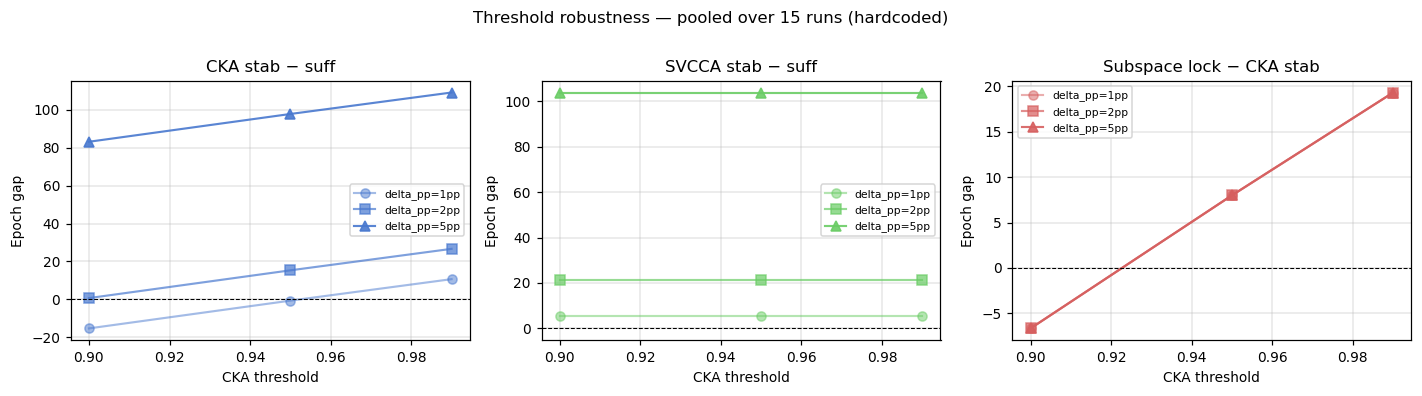

In [27]:
# ── plot: gaps vs threshold ───────────────────────────────────────────────────
if sweep_df is not None:
    thresholds = sorted(sweep_df.cka_thresh.unique())
    delta_pps  = sorted(sweep_df.delta_pp.unique())
    gap_cols   = ['gap_cka', 'gap_svcca', 'gap_lock_vs_cka']
    gap_labels = {'gap_cka': 'CKA stab − suff', 'gap_svcca': 'SVCCA stab − suff',
                  'gap_lock_vs_cka': 'Subspace lock − CKA stab'}
    colors_g   = {'gap_cka': '#4878CF', 'gap_svcca': '#6ACC65', 'gap_lock_vs_cka': '#D65F5F'}
    markers_d  = {1: 'o', 2: 's', 5: '^'}

    fig, axes = plt.subplots(1, len(gap_cols), figsize=(13, 3.5), sharey=False)
    for ax, gc in zip(axes, gap_cols):
        for dp in delta_pps:
            sub_s = sweep_df[sweep_df.delta_pp == dp].sort_values('cka_thresh')
            ax.plot(sub_s.cka_thresh, sub_s[gc],
                    marker=markers_d.get(dp, 'o'), lw=1.4,
                    color=colors_g[gc], alpha=0.5 + 0.2 * delta_pps.index(dp),
                    label=f'delta_pp={dp}pp')
        ax.axhline(0, color='k', lw=0.7, ls='--')
        ax.set_xlabel('CKA threshold')
        ax.set_ylabel('Epoch gap')
        ax.set_title(gap_labels.get(gc, gc))
        ax.legend(fontsize=7)
        ax.grid(True, lw=0.3)
    fig.suptitle('Threshold robustness — pooled over 15 runs (hardcoded)', y=1.01)
    plt.tight_layout()
    plt.show()

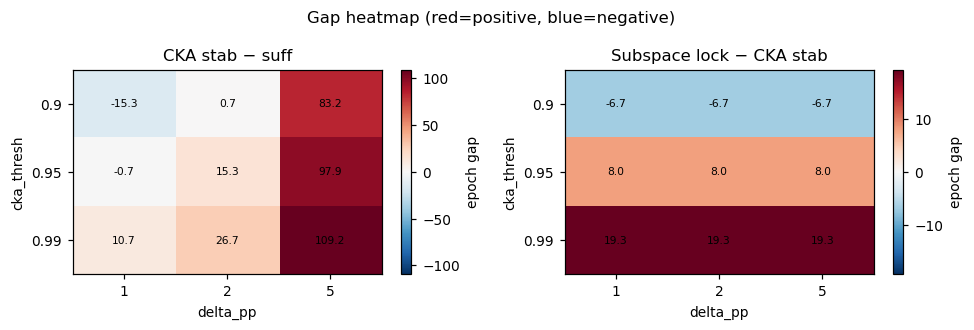

In [28]:
# ── alternative view: heatmap of gap_cka and gap_lock_vs_cka ─────────────────
if sweep_df is not None:
    fig, axes = plt.subplots(1, 2, figsize=(9, 3))
    for ax, gc in zip(axes, ['gap_cka', 'gap_lock_vs_cka']):
        pivot = sweep_df.pivot(index='cka_thresh', columns='delta_pp', values=gc)
        im = ax.imshow(pivot.values, aspect='auto', cmap='RdBu_r',
                       vmin=-max(abs(sweep_df[gc])), vmax=max(abs(sweep_df[gc])))
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel('delta_pp')
        ax.set_ylabel('cka_thresh')
        ax.set_title(gap_labels.get(gc, gc))
        plt.colorbar(im, ax=ax, label='epoch gap')
        # annotate cells
        for (r, c), val in np.ndenumerate(pivot.values):
            ax.text(c, r, f'{val:.1f}', ha='center', va='center', fontsize=7)
    fig.suptitle('Gap heatmap (red=positive, blue=negative)')
    plt.tight_layout()
    plt.show()